            # Week 4 - Violations Detection

            This notebook translates the motion dataset into a telematics-style violation problem.

            Because the source file does not provide explicit event labels such as `overspeed_flag` or `hard_brake_flag`,
            we derive proxy violation labels from high-intensity motion events and dominant class behavior.

            ## Target

            `violation_flag = 1` when a trip's violation score is at or above the dataset median.
            


In [1]:
            !pip install pandas numpy matplotlib seaborn scikit-learn
            


In [2]:
            from pathlib import Path
            import pandas as pd
            import seaborn as sns
            import matplotlib.pyplot as plt
            from sklearn.model_selection import train_test_split
            from sklearn.ensemble import RandomForestClassifier
            from sklearn.metrics import classification_report, confusion_matrix

            BASE_DIR = Path(r"/Users/ayet_dub/Documents/Codex/2026-05-11/files-mentioned-by-the-user-test")
            trip_df = pd.read_csv(BASE_DIR / "data" / "telematics_trip_summary.csv")
            


In [3]:
            feature_cols = [
                "avg_acc_mag",
                "max_acc_mag",
                "std_acc_mag",
                "avg_gyro_mag",
                "max_gyro_mag",
                "avg_jerk_mag",
                "harsh_accel_events",
                "sharp_turn_events",
                "sudden_motion_events",
                "samples",
                "duration_ticks",
            ]

            X = trip_df[feature_cols]
            y = trip_df["violation_flag"]

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.25, random_state=42, stratify=y
            )
            


In [4]:
            clf = RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
            )
            clf.fit(X_train, y_train)

            pred = clf.predict(X_test)
            print(classification_report(y_test, pred))
            


              precision    recall  f1-score   support

           0       0.73      0.79      0.76        14
           1       0.79      0.73      0.76        15

    accuracy                           0.76        29
   macro avg       0.76      0.76      0.76        29
weighted avg       0.76      0.76      0.76        29



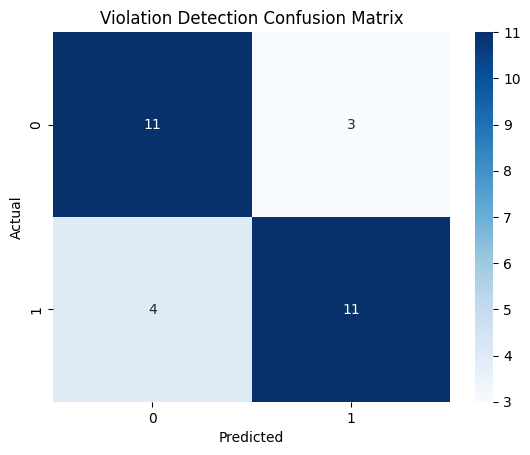

In [5]:
            cm = confusion_matrix(y_test, pred)
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
            plt.title("Violation Detection Confusion Matrix")
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.show()
            


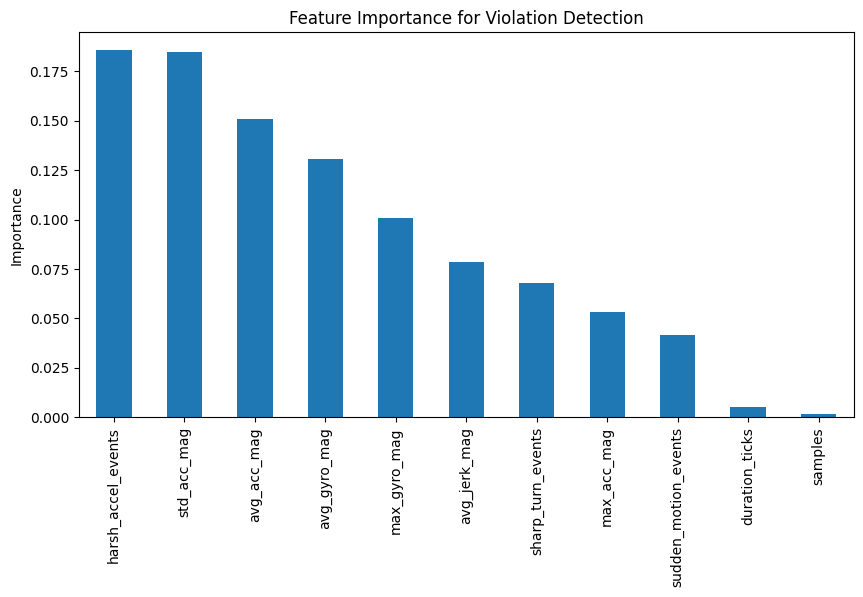

In [6]:
            importances = (
                pd.Series(clf.feature_importances_, index=feature_cols)
                .sort_values(ascending=False)
            )

            importances.plot(kind="bar", figsize=(10, 5), color="#1f77b4")
            plt.title("Feature Importance for Violation Detection")
            plt.ylabel("Importance")
            plt.show()
            


The violation detection model found that sudden acceleration, unstable movement, and strong turning were the strongest signs of risky driving.

The model performed fairly well, with 76% accuracy. It correctly detected many safe and risky trips, but it still made a few mistakes, so it is not perfect yet.

Overall, this model can help the driver monitoring dashboard flag possible unsafe trips, identify drivers who may need coaching, and support early review before problems become more serious.